In [1]:
import os
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import polars as pl
import seaborn as sns
import sys

sys.path.insert(0, os.path.abspath("../.."))
sys.path

from util import load_config_from_checkpoint

pl.Config.set_tbl_rows(16)

polars.config.Config

In [2]:
with open("accuracy_results.txt", "r") as f:
    checkpoints, metric_names, metric_means, metric_ses = [], [], [], []
    for line in f.readlines():
        model_part, metric_part = line.strip().split(" | ")
        model_header, model_checkpoint = model_part.split(" = ")
        metric_name, metric_full_value = metric_part.split(" = ")
        metric_mean, metric_se = metric_full_value.split(" +- ")
        checkpoints.append(model_checkpoint)
        metric_names.append(metric_name)
        metric_means.append(float(metric_mean))
        metric_ses.append(float(metric_se))
results_df = pl.DataFrame({"Checkpoint": checkpoints, "Metric": metric_names, "Mean": metric_means, "SE": metric_ses})

results_df

Checkpoint,Metric,Mean,SE
str,str,f64,f64
"""ELSA-512-4b5642c8""","""Recall @ 20""",0.330508,0.001918
"""ELSA-1024-c6d19aef""","""Recall @ 20""",0.340071,0.001928
"""ELSA-2048-9369e42e""","""Recall @ 20""",0.344297,0.001928
"""BasicSAE-2048-e05d8419""","""Cosine similarity""",0.576595,0.001603
"""BasicSAE-2048-e05d8419""","""Recall @ 20 degradation""",-0.165017,0.001754
"""BasicSAE-2048-0bff8656""","""Cosine similarity""",0.756362,0.001446
"""BasicSAE-2048-0bff8656""","""Recall @ 20 degradation""",-0.072113,0.001308
"""BasicSAE-2048-739966c4""","""Cosine similarity""",0.877717,0.000728
…,…,…,…


In [3]:
with open("training_losses.txt", "r") as f:
    checkpoints, train_l2s, train_l1s, train_l0s, val_l2s, val_l1s, val_l0s = [], [], [], [], [], [], []
    for line in f.readlines():
        if line.startswith("Model"):
            checkpoints.append(line.strip().split(" | ")[0].split(" = ")[1])
        else:
            train_losses, val_losses = line.split("s, ")[1].strip()[:-1].replace(" ", "").split("|")
            train_losses = {s.split("=")[0]: float(s.split("=")[1]) for s in train_losses.split(",")}
            val_losses = {s.split("=")[0]: float(s.split("=")[1]) for s in val_losses.replace("Val:", "").split(",")}
            train_l2s.append(train_losses["L2"])
            train_l1s.append(train_losses["L1"])
            train_l0s.append(train_losses["L0"])
            val_l2s.append(val_losses["L2"])
            val_l1s.append(val_losses["L1"])
            val_l0s.append(val_losses["L0"])
losses_df = pl.DataFrame(
    {
        "Checkpoint": checkpoints,
        "Train L2": train_l2s,
        "Train L1": train_l1s,
        "Train L0": train_l0s,
        "Val L2": val_l2s,
        "Val L1": val_l1s,
        "Val L0": val_l0s,
    }
)

losses_df

Checkpoint,Train L2,Train L1,Train L0,Val L2,Val L1,Val L0
str,f64,f64,f64,f64,f64,f64
"""BasicSAE-2048-e05d8419""",0.677,7.23,1.23,0.676,7.114,1.262
"""BasicSAE-2048-0bff8656""",0.475,31.1,4.89,0.47,31.974,5.184
"""BasicSAE-2048-739966c4""",0.262,79.5,18.2,0.285,80.461,18.361
"""BasicSAE-2048-349d9604""",0.166,133.0,43.4,0.193,129.51,42.973
"""BasicSAE-4096-1443eff9""",0.669,7.22,1.3,0.668,7.652,1.378
"""BasicSAE-4096-51025ce1""",0.48,30.2,4.58,0.486,30.391,4.682
"""BasicSAE-4096-a99d7c6c""",0.268,81.7,19.0,0.283,80.355,19.442
"""BasicSAE-4096-882a8d66""",0.147,141.0,48.6,0.184,131.641,48.818
…,…,…,…,…,…,…


In [4]:
elsa_results = results_df.filter(pl.col("Checkpoint").str.starts_with("ELSA"))
sae_results = results_df.filter(~pl.col("Checkpoint").str.starts_with("ELSA"))

sae_results

Checkpoint,Metric,Mean,SE
str,str,f64,f64
"""BasicSAE-2048-e05d8419""","""Cosine similarity""",0.576595,0.001603
"""BasicSAE-2048-e05d8419""","""Recall @ 20 degradation""",-0.165017,0.001754
"""BasicSAE-2048-0bff8656""","""Cosine similarity""",0.756362,0.001446
"""BasicSAE-2048-0bff8656""","""Recall @ 20 degradation""",-0.072113,0.001308
"""BasicSAE-2048-739966c4""","""Cosine similarity""",0.877717,0.000728
"""BasicSAE-2048-739966c4""","""Recall @ 20 degradation""",-0.025426,0.000956
"""BasicSAE-2048-349d9604""","""Cosine similarity""",0.924305,0.000431
"""BasicSAE-2048-349d9604""","""Recall @ 20 degradation""",-0.014276,0.000822
…,…,…,…


In [5]:
elsa_dim_to_recall = {int(k.split("-")[1]): v for k, v in zip(elsa_results["Checkpoint"], elsa_results["Mean"])}
checkpoints = sae_results["Checkpoint"].unique()
sae_configs = {}
for checkpoint in checkpoints:
    sae_configs[checkpoint] = load_config_from_checkpoint(f"../../checkpoints/ml-25m/{checkpoint}.ckpt")

configs = pl.DataFrame(
    {
        "Checkpoint": checkpoints.to_list(),
        "SAE variant": [sae_configs[x]["model_class"] for x in checkpoints.to_list()],
        "SAE input dim": [int(sae_configs[x]["pretrained_model_checkpoint"].split("-")[1]) for x in checkpoints.to_list()],
        "SAE embedding dim": [sae_configs[x]["embedding_dim"] for x in checkpoints.to_list()],
        "k": [sae_configs[x]["k"] for x in checkpoints.to_list()],
        "l1": [sae_configs[x]["l1_coef"] for x in checkpoints.to_list()],
    }
).with_columns(
    pl.when(pl.col("SAE variant") == "BasicSAE")
    .then(-1)
    .otherwise(pl.col("k"))
    .alias("k")  # k is not a parameter of BasicSAE (but SAEs share config structure)
)

sae_results = sae_results.join(configs, on="Checkpoint").with_columns(
    pl.col("SAE variant").replace_strict({"BasicSAE": "Basic SAE", "TopKSAE": "TopK SAE"}).alias("SAE variant")
)

sae_results

Checkpoint,Metric,Mean,SE,SAE variant,SAE input dim,SAE embedding dim,k,l1
str,str,f64,f64,str,i64,i64,i64,f64
"""BasicSAE-2048-e05d8419""","""Cosine similarity""",0.576595,0.001603,"""Basic SAE""",1024,2048,-1,0.01
"""BasicSAE-2048-e05d8419""","""Recall @ 20 degradation""",-0.165017,0.001754,"""Basic SAE""",1024,2048,-1,0.01
"""BasicSAE-2048-0bff8656""","""Cosine similarity""",0.756362,0.001446,"""Basic SAE""",1024,2048,-1,0.005
"""BasicSAE-2048-0bff8656""","""Recall @ 20 degradation""",-0.072113,0.001308,"""Basic SAE""",1024,2048,-1,0.005
"""BasicSAE-2048-739966c4""","""Cosine similarity""",0.877717,0.000728,"""Basic SAE""",1024,2048,-1,0.002
"""BasicSAE-2048-739966c4""","""Recall @ 20 degradation""",-0.025426,0.000956,"""Basic SAE""",1024,2048,-1,0.002
"""BasicSAE-2048-349d9604""","""Cosine similarity""",0.924305,0.000431,"""Basic SAE""",1024,2048,-1,0.001
"""BasicSAE-2048-349d9604""","""Recall @ 20 degradation""",-0.014276,0.000822,"""Basic SAE""",1024,2048,-1,0.001
…,…,…,…,…,…,…,…,…


# Model leaderboards

## Cosine similarity

### Per SAE input dim

In [6]:
sae_results.filter(pl.col("Metric") == "Cosine similarity").sort(by="Mean", descending=True).group_by(["Metric", "SAE input dim", "SAE variant"]).agg(
    pl.first("Checkpoint"), pl.first("Mean")
).sort(["SAE input dim", "Mean"], descending=[False, True])

Metric,SAE input dim,SAE variant,Checkpoint,Mean
str,i64,str,str,f64
"""Cosine similarity""",512,"""Basic SAE""","""BasicSAE-4096-643bbad1""",0.959604
"""Cosine similarity""",512,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",0.955696
"""Cosine similarity""",1024,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",0.932936
"""Cosine similarity""",1024,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",0.931644
"""Cosine similarity""",2048,"""Basic SAE""","""BasicSAE-8192-9de9f940""",0.848382
"""Cosine similarity""",2048,"""TopK SAE""","""TopKSAE-4096-36814cc7""",0.847398


### Per SAE embedding dim

In [7]:
sae_results.filter(pl.col("Metric") == "Cosine similarity").sort(by="Mean", descending=True).group_by(["Metric", "SAE embedding dim", "SAE variant"]).agg(
    pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")
).sort(["SAE embedding dim", "Mean"], descending=[False, True])

Metric,SAE embedding dim,SAE variant,Checkpoint,SAE input dim,Mean
str,i64,str,str,i64,f64
"""Cosine similarity""",1024,"""TopK SAE""","""TopKSAE-1024-4ca6aa9c""",512,0.948242
"""Cosine similarity""",1024,"""Basic SAE""","""BasicSAE-1024-e118489e""",512,0.948114
"""Cosine similarity""",2048,"""Basic SAE""","""BasicSAE-2048-54616428""",512,0.955325
"""Cosine similarity""",2048,"""TopK SAE""","""TopKSAE-2048-6ab414fc""",512,0.953519
"""Cosine similarity""",4096,"""Basic SAE""","""BasicSAE-4096-643bbad1""",512,0.959604
"""Cosine similarity""",4096,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",512,0.955696
"""Cosine similarity""",8192,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",1024,0.932936
"""Cosine similarity""",8192,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",1024,0.931644
"""Cosine similarity""",16384,"""Basic SAE""","""BasicSAE-16384-3ad9a664""",2048,0.847653


### Per L1 hyperparameter

In [8]:
sae_results.filter(pl.col("Metric") == "Cosine similarity").filter(pl.col("SAE variant") == "Basic SAE").sort(by="Mean", descending=True).group_by(
    ["Metric", "l1", "SAE variant"]
).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(["l1", "Mean"], descending=[False, True])

Metric,l1,SAE variant,Checkpoint,SAE input dim,Mean
str,f64,str,str,i64,f64
"""Cosine similarity""",0.001,"""Basic SAE""","""BasicSAE-4096-643bbad1""",512,0.959604
"""Cosine similarity""",0.002,"""Basic SAE""","""BasicSAE-4096-80c1695a""",512,0.942751
"""Cosine similarity""",0.005,"""Basic SAE""","""BasicSAE-4096-7ba9e65c""",512,0.890505
"""Cosine similarity""",0.01,"""Basic SAE""","""BasicSAE-1024-2bf5b284""",512,0.8147


### Per K hyperparameter

In [9]:
sae_results.filter(pl.col("Metric") == "Cosine similarity").filter(pl.col("SAE variant") == "TopK SAE").sort(by="Mean", descending=True).group_by(
    ["Metric", "k", "SAE variant"]
).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(["k", "Mean"], descending=[False, True])

Metric,k,SAE variant,Checkpoint,SAE input dim,Mean
str,i64,str,str,i64,f64
"""Cosine similarity""",8,"""TopK SAE""","""TopKSAE-2048-434e1bb3""",512,0.89472
"""Cosine similarity""",16,"""TopK SAE""","""TopKSAE-4096-80968dee""",512,0.922406
"""Cosine similarity""",32,"""TopK SAE""","""TopKSAE-4096-9713537f""",512,0.943215
"""Cosine similarity""",64,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",512,0.955696


## Recall @ 20 degradation

### Per SAE input dim

In [10]:
sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation").sort(by="Mean", descending=True).group_by(["Metric", "SAE input dim", "SAE variant"]).agg(
    pl.first("Checkpoint"), pl.first("Mean")
).sort(["SAE input dim", "Mean"], descending=[False, True])

Metric,SAE input dim,SAE variant,Checkpoint,Mean
str,i64,str,str,f64
"""Recall @ 20 degradation""",512,"""Basic SAE""","""BasicSAE-4096-643bbad1""",-0.005671
"""Recall @ 20 degradation""",512,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",-0.006882
"""Recall @ 20 degradation""",1024,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",-0.011923
"""Recall @ 20 degradation""",1024,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",-0.012109
"""Recall @ 20 degradation""",2048,"""Basic SAE""","""BasicSAE-16384-3ad9a664""",-0.028921
"""Recall @ 20 degradation""",2048,"""TopK SAE""","""TopKSAE-4096-36814cc7""",-0.029384


### Per SAE embedding dim

In [11]:
sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation").sort(by="Mean", descending=True).group_by(["Metric", "SAE embedding dim", "SAE variant"]).agg(
    pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")
).sort(["SAE embedding dim", "Mean"], descending=[False, True])

Metric,SAE embedding dim,SAE variant,Checkpoint,SAE input dim,Mean
str,i64,str,str,i64,f64
"""Recall @ 20 degradation""",1024,"""TopK SAE""","""TopKSAE-1024-4ca6aa9c""",512,-0.008138
"""Recall @ 20 degradation""",1024,"""Basic SAE""","""BasicSAE-1024-e118489e""",512,-0.008608
"""Recall @ 20 degradation""",2048,"""TopK SAE""","""TopKSAE-2048-6ab414fc""",512,-0.006921
"""Recall @ 20 degradation""",2048,"""Basic SAE""","""BasicSAE-2048-54616428""",512,-0.006942
"""Recall @ 20 degradation""",4096,"""Basic SAE""","""BasicSAE-4096-643bbad1""",512,-0.005671
"""Recall @ 20 degradation""",4096,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",512,-0.006882
"""Recall @ 20 degradation""",8192,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",1024,-0.011923
"""Recall @ 20 degradation""",8192,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",1024,-0.012109
"""Recall @ 20 degradation""",16384,"""Basic SAE""","""BasicSAE-16384-3ad9a664""",2048,-0.028921


### Per L1 hyperparameter

In [12]:
sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation").filter(pl.col("SAE variant") == "Basic SAE").sort(by="Mean", descending=True).group_by(
    ["Metric", "l1", "SAE variant"]
).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(["l1", "Mean"], descending=[False, True])

Metric,l1,SAE variant,Checkpoint,SAE input dim,Mean
str,f64,str,str,i64,f64
"""Recall @ 20 degradation""",0.001,"""Basic SAE""","""BasicSAE-4096-643bbad1""",512,-0.005671
"""Recall @ 20 degradation""",0.002,"""Basic SAE""","""BasicSAE-4096-80c1695a""",512,-0.009039
"""Recall @ 20 degradation""",0.005,"""Basic SAE""","""BasicSAE-2048-7d3cc060""",512,-0.023759
"""Recall @ 20 degradation""",0.01,"""Basic SAE""","""BasicSAE-1024-2bf5b284""",512,-0.051683


### Per K hyperparameter

In [13]:
sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation").filter(pl.col("SAE variant") == "TopK SAE").sort(by="Mean", descending=True).group_by(
    ["Metric", "k", "SAE variant"]
).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(["k", "Mean"], descending=[False, True])

Metric,k,SAE variant,Checkpoint,SAE input dim,Mean
str,i64,str,str,i64,f64
"""Recall @ 20 degradation""",8,"""TopK SAE""","""TopKSAE-1024-e2b1e64e""",512,-0.022852
"""Recall @ 20 degradation""",16,"""TopK SAE""","""TopKSAE-4096-80968dee""",512,-0.014152
"""Recall @ 20 degradation""",32,"""TopK SAE""","""TopKSAE-4096-9713537f""",512,-0.009222
"""Recall @ 20 degradation""",64,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",512,-0.006882


## Recall @ 20

### Per SAE input dim

In [14]:
sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation").with_columns(pl.col("Metric").replace_strict("Recall @ 20 degradation", "Recall @ 20")).drop(
    "SE"
).with_columns((pl.col("SAE input dim").replace_strict(elsa_dim_to_recall) + pl.col("Mean")).alias("Mean")).sort(by="Mean", descending=True).group_by(
    ["Metric", "SAE input dim", "SAE variant"]
).agg(pl.first("Checkpoint"), pl.first("Mean")).sort(["SAE input dim", "Mean"], descending=[False, True])

Metric,SAE input dim,SAE variant,Checkpoint,Mean
str,i64,str,str,f64
"""Recall @ 20""",512,"""Basic SAE""","""BasicSAE-4096-643bbad1""",0.324837
"""Recall @ 20""",512,"""TopK SAE""","""TopKSAE-4096-7e178d1f""",0.323626
"""Recall @ 20""",1024,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",0.328148
"""Recall @ 20""",1024,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",0.327962
"""Recall @ 20""",2048,"""Basic SAE""","""BasicSAE-16384-3ad9a664""",0.315376
"""Recall @ 20""",2048,"""TopK SAE""","""TopKSAE-4096-36814cc7""",0.314913


### Per SAE embedding dim

In [15]:
sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation").with_columns(pl.col("Metric").replace_strict("Recall @ 20 degradation", "Recall @ 20")).drop(
    "SE"
).with_columns((pl.col("SAE input dim").replace_strict(elsa_dim_to_recall) + pl.col("Mean")).alias("Mean")).sort(by="Mean", descending=True).group_by(
    ["Metric", "SAE embedding dim", "SAE variant"]
).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(["SAE embedding dim", "Mean"], descending=[False, True])

Metric,SAE embedding dim,SAE variant,Checkpoint,SAE input dim,Mean
str,i64,str,str,i64,f64
"""Recall @ 20""",1024,"""TopK SAE""","""TopKSAE-1024-4ca6aa9c""",512,0.32237
"""Recall @ 20""",1024,"""Basic SAE""","""BasicSAE-1024-e118489e""",512,0.3219
"""Recall @ 20""",2048,"""Basic SAE""","""BasicSAE-2048-349d9604""",1024,0.325795
"""Recall @ 20""",2048,"""TopK SAE""","""TopKSAE-2048-b6471c70""",1024,0.325435
"""Recall @ 20""",4096,"""TopK SAE""","""TopKSAE-4096-2f73f56a""",1024,0.327506
"""Recall @ 20""",4096,"""Basic SAE""","""BasicSAE-4096-882a8d66""",1024,0.326409
"""Recall @ 20""",8192,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",1024,0.328148
"""Recall @ 20""",8192,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",1024,0.327962
"""Recall @ 20""",16384,"""Basic SAE""","""BasicSAE-16384-3ad9a664""",2048,0.315376


In [16]:
sae_results.filter((pl.col("SAE variant") == "Basic SAE") & (pl.col("Metric") == "Recall @ 20 degradation")).with_columns(
    pl.col("Metric").replace_strict("Recall @ 20 degradation", "Recall @ 20")
).drop("SE").with_columns((pl.col("SAE input dim").replace_strict(elsa_dim_to_recall) + pl.col("Mean")).alias("Mean")).sort(
    by="Mean", descending=True
).group_by(["Metric", "l1", "SAE variant"]).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(
    ["l1", "Mean"], descending=[False, True]
)

Metric,l1,SAE variant,Checkpoint,SAE input dim,Mean
str,f64,str,str,i64,f64
"""Recall @ 20""",0.001,"""Basic SAE""","""BasicSAE-8192-da3fa8d1""",1024,0.328148
"""Recall @ 20""",0.002,"""Basic SAE""","""BasicSAE-4096-80c1695a""",512,0.321469
"""Recall @ 20""",0.005,"""Basic SAE""","""BasicSAE-2048-7d3cc060""",512,0.306749
"""Recall @ 20""",0.01,"""Basic SAE""","""BasicSAE-1024-2bf5b284""",512,0.278825


In [17]:
sae_results.filter((pl.col("SAE variant") == "TopK SAE") & (pl.col("Metric") == "Recall @ 20 degradation")).with_columns(
    pl.col("Metric").replace_strict("Recall @ 20 degradation", "Recall @ 20")
).drop("SE").with_columns((pl.col("SAE input dim").replace_strict(elsa_dim_to_recall) + pl.col("Mean")).alias("Mean")).sort(
    by="Mean", descending=True
).group_by(["Metric", "k", "SAE variant"]).agg(pl.first("Checkpoint"), pl.first("SAE input dim"), pl.first("Mean")).sort(
    ["k", "Mean"], descending=[False, True]
)

Metric,k,SAE variant,Checkpoint,SAE input dim,Mean
str,i64,str,str,i64,f64
"""Recall @ 20""",8,"""TopK SAE""","""TopKSAE-2048-0399cdb3""",1024,0.311822
"""Recall @ 20""",16,"""TopK SAE""","""TopKSAE-4096-aac66fc3""",1024,0.32122
"""Recall @ 20""",32,"""TopK SAE""","""TopKSAE-4096-97c35d9e""",1024,0.326117
"""Recall @ 20""",64,"""TopK SAE""","""TopKSAE-8192-aa3ebf62""",1024,0.327962


# Plots

## All variants and sizes

In [18]:
cosine_results = sae_results.filter(pl.col("Metric") == "Cosine similarity")
recall_degradation_results = sae_results.filter(pl.col("Metric") == "Recall @ 20 degradation")
recall_results = (
    recall_degradation_results.with_columns(pl.col("Metric").replace_strict("Recall @ 20 degradation", "Recall @ 20"))
    .drop("SE")
    .with_columns((pl.col("SAE input dim").replace_strict(elsa_dim_to_recall) + pl.col("Mean")).alias("Mean"))
)

### Activation width vs quality

#### Cosine similarity

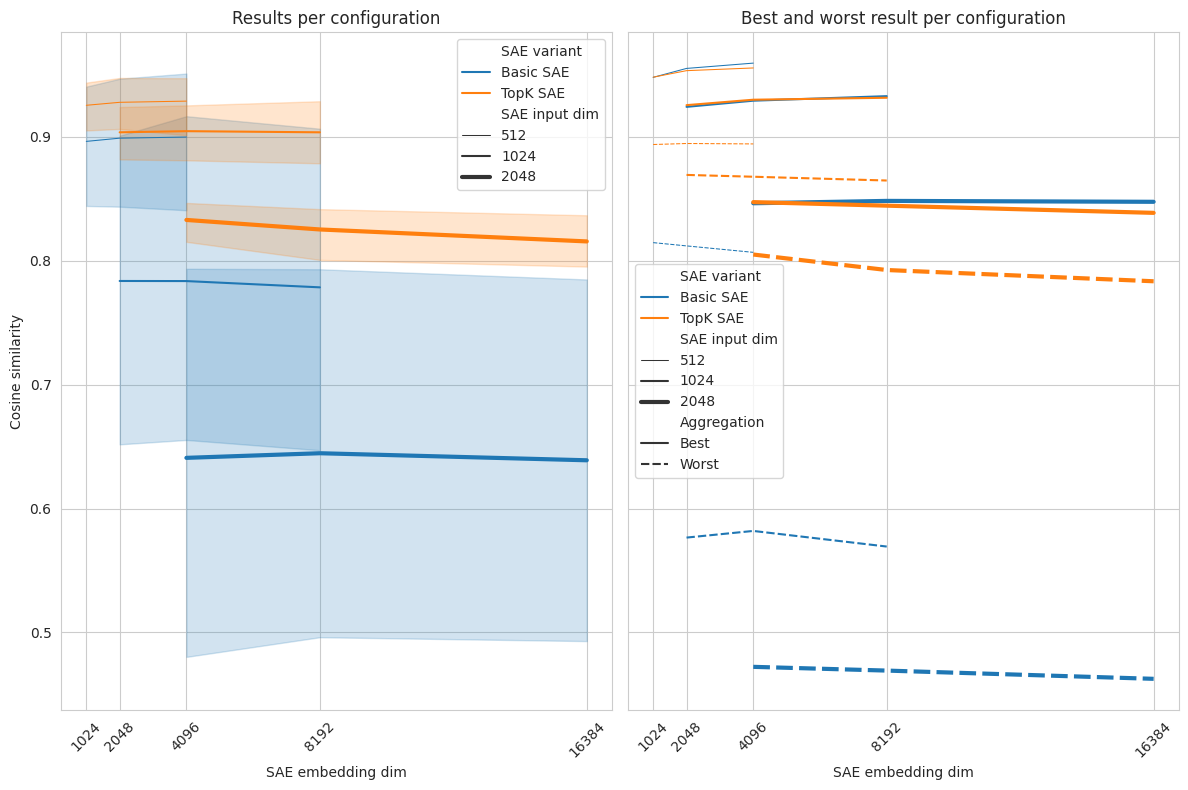

In [19]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

sns.lineplot(data=cosine_results, x="SAE embedding dim", y="Mean", size="SAE input dim", hue="SAE variant", ax=axes[0])
axes[0].set_xticks(cosine_results["SAE embedding dim"].unique())
axes[0].set_xticklabels(cosine_results["SAE embedding dim"].unique(), rotation=45)
axes[0].set_title("Results per configuration")
axes[0].set_ylabel("Cosine similarity")

sns.lineplot(
    data=pl.concat(
        [
            cosine_results.group_by(["SAE variant", "SAE input dim", "SAE embedding dim"])
            .agg(pl.max("Mean").alias("Value"))
            .with_columns(pl.lit("Best").alias("Aggregation")),
            cosine_results.group_by(["SAE variant", "SAE input dim", "SAE embedding dim"])
            .agg(pl.min("Mean").alias("Value"))
            .with_columns(pl.lit("Worst").alias("Aggregation")),
        ],
    ).sort(by=["SAE variant", "SAE input dim", "SAE embedding dim", "Aggregation"]),
    x="SAE embedding dim",
    y="Value",
    size="SAE input dim",
    style="Aggregation",
    hue="SAE variant",
    ax=axes[1],
)
axes[1].set_xticks(cosine_results["SAE embedding dim"].unique())
axes[1].set_xticklabels(cosine_results["SAE embedding dim"].unique(), rotation=45)
axes[1].set_title("Best and worst result per configuration")
axes[1].set_ylabel("Cosine similarity")

plt.tight_layout()

#### Recall @ 20 degradation

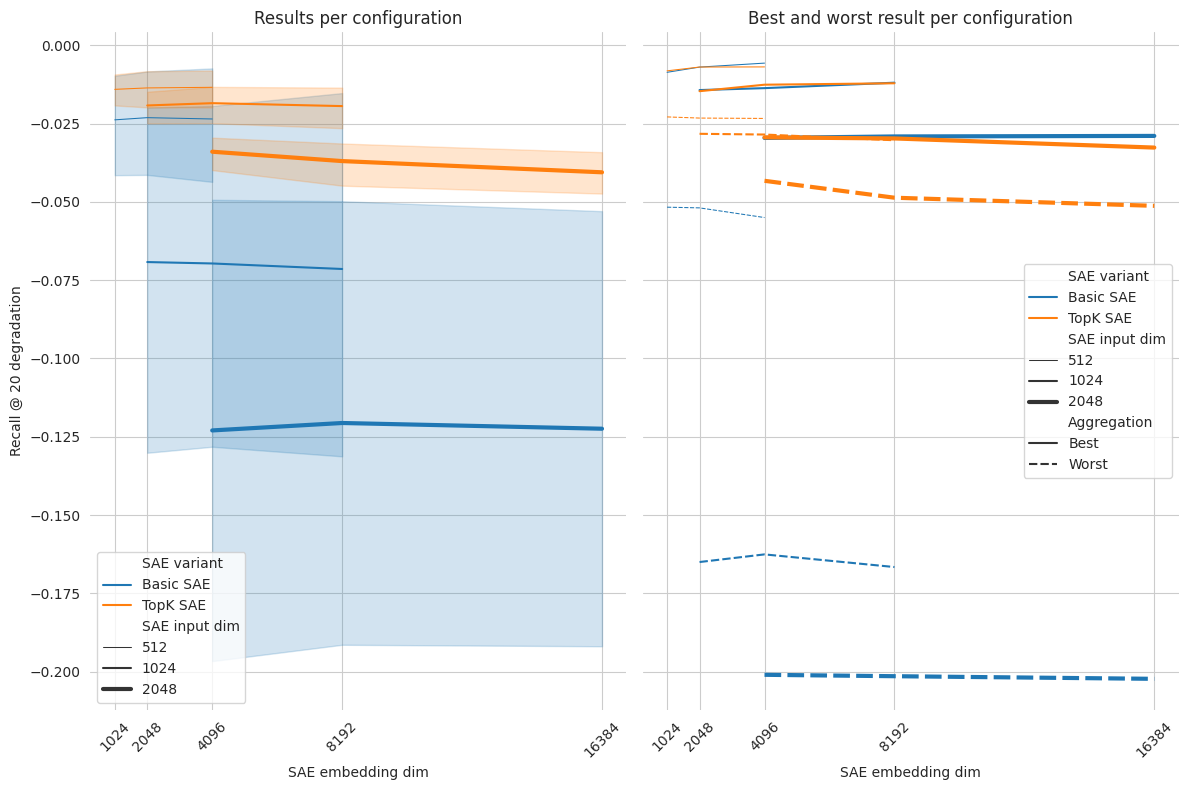

In [20]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

sns.lineplot(data=recall_degradation_results, x="SAE embedding dim", y="Mean", size="SAE input dim", hue="SAE variant", ax=axes[0])
axes[0].set_xticks(recall_degradation_results["SAE embedding dim"].unique())
axes[0].set_xticklabels(recall_degradation_results["SAE embedding dim"].unique(), rotation=45)
axes[0].set_title("Results per configuration")
axes[0].set_ylabel("Recall @ 20 degradation")

sns.lineplot(
    data=pl.concat(
        [
            recall_degradation_results.group_by(["SAE variant", "SAE input dim", "SAE embedding dim"])
            .agg(pl.max("Mean").alias("Value"))
            .with_columns(pl.lit("Best").alias("Aggregation")),
            recall_degradation_results.group_by(["SAE variant", "SAE input dim", "SAE embedding dim"])
            .agg(pl.min("Mean").alias("Value"))
            .with_columns(pl.lit("Worst").alias("Aggregation")),
        ],
    ).sort(by=["SAE variant", "SAE input dim", "SAE embedding dim", "Aggregation"]),
    x="SAE embedding dim",
    y="Value",
    size="SAE input dim",
    style="Aggregation",
    hue="SAE variant",
    ax=axes[1],
)
axes[1].set_xticks(recall_degradation_results["SAE embedding dim"].unique())
axes[1].set_xticklabels(recall_degradation_results["SAE embedding dim"].unique(), rotation=45)
axes[1].set_title("Best and worst result per configuration")
axes[1].set_ylabel("Recall @ 20 degradation")

sns.despine(bottom=True, left=True)
plt.tight_layout()

#### Recall @ 20

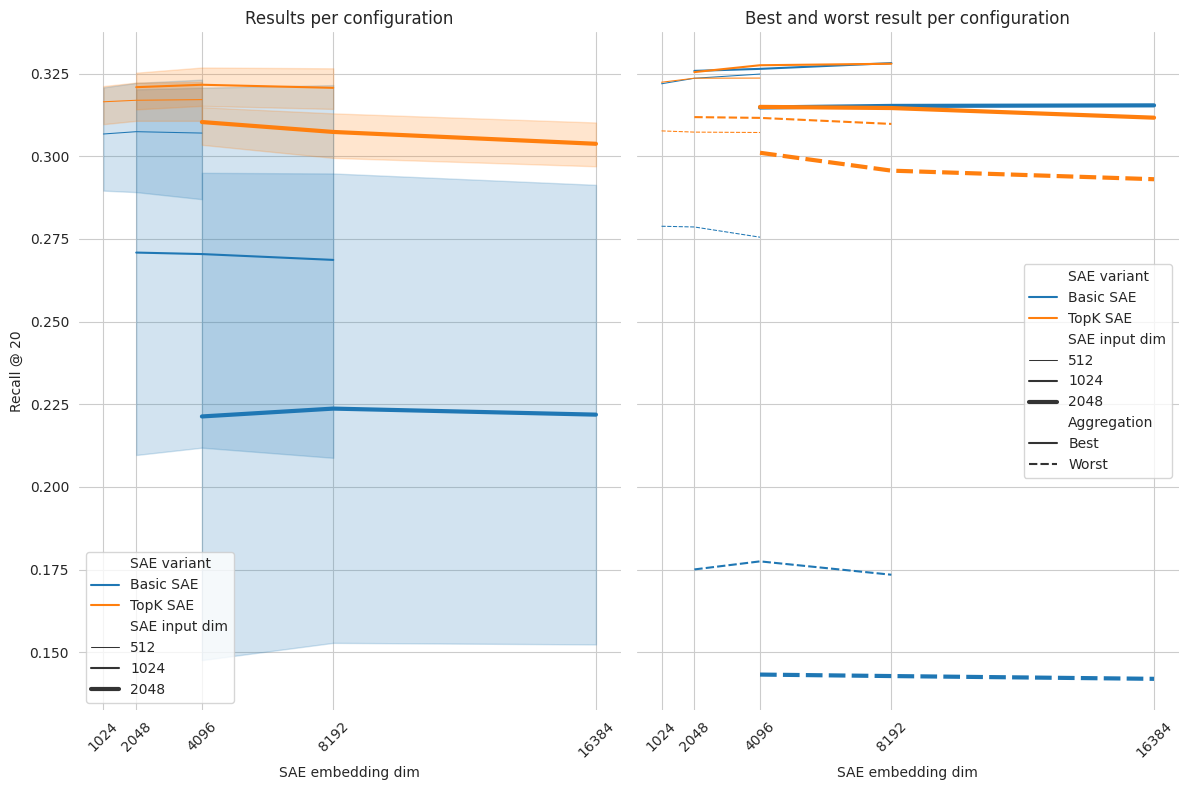

In [21]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

sns.lineplot(data=recall_results, x="SAE embedding dim", y="Mean", size="SAE input dim", hue="SAE variant", ax=axes[0])
axes[0].set_xticks(recall_results["SAE embedding dim"].unique())
axes[0].set_xticklabels(recall_results["SAE embedding dim"].unique(), rotation=45)
axes[0].set_title("Results per configuration")
axes[0].set_ylabel("Recall @ 20")

sns.lineplot(
    data=pl.concat(
        [
            recall_results.group_by(["SAE variant", "SAE input dim", "SAE embedding dim"])
            .agg(pl.max("Mean").alias("Value"))
            .with_columns(pl.lit("Best").alias("Aggregation")),
            recall_results.group_by(["SAE variant", "SAE input dim", "SAE embedding dim"])
            .agg(pl.min("Mean").alias("Value"))
            .with_columns(pl.lit("Worst").alias("Aggregation")),
        ],
    ).sort(by=["SAE variant", "SAE input dim", "SAE embedding dim", "Aggregation"]),
    x="SAE embedding dim",
    y="Value",
    size="SAE input dim",
    style="Aggregation",
    hue="SAE variant",
    ax=axes[1],
)
axes[1].set_xticks(recall_results["SAE embedding dim"].unique())
axes[1].set_xticklabels(recall_results["SAE embedding dim"].unique(), rotation=45)
axes[1].set_title("Best and worst result per configuration")
axes[1].set_ylabel("Recall @ 20")

sns.despine(bottom=True, left=True)
plt.tight_layout()

### Activation sparsity vs quality

#### Cosine similarity

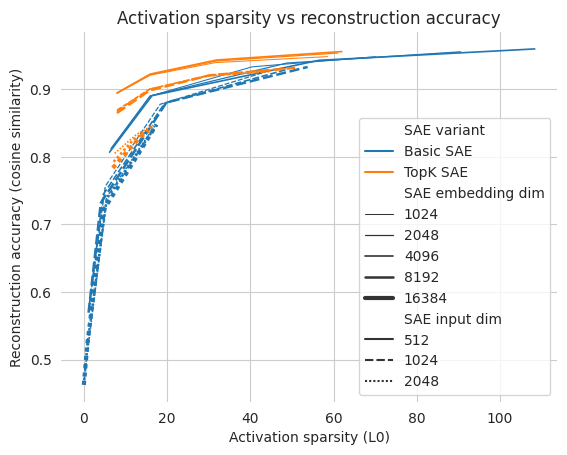

In [22]:
sns.set_style("whitegrid")
sns.lineplot(
    cosine_results.join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="Val L0",
    y="Mean",
    hue="SAE variant",
    style="SAE input dim",
    size="SAE embedding dim",
)
plt.title("Activation sparsity vs reconstruction accuracy")
plt.xlabel("Activation sparsity (L0)")
plt.ylabel("Reconstruction accuracy (cosine similarity)")
sns.despine(bottom=True, left=True)

#### Recall @ 20 degradation

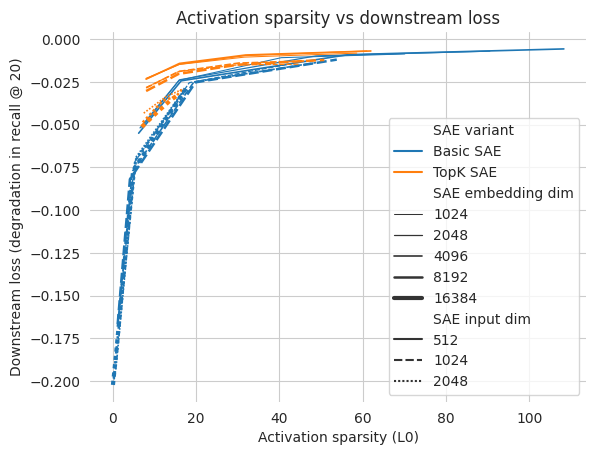

In [23]:
sns.set_style("whitegrid")
sns.lineplot(
    recall_degradation_results.join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="Val L0",
    y="Mean",
    hue="SAE variant",
    style="SAE input dim",
    size="SAE embedding dim",
)
plt.title("Activation sparsity vs downstream loss")
plt.xlabel("Activation sparsity (L0)")
plt.ylabel("Downstream loss (degradation in recall @ 20)")
sns.despine(bottom=True, left=True)

#### Recall @ 20

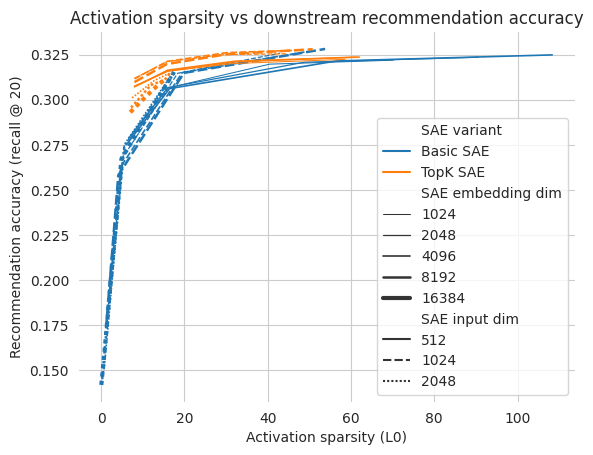

In [24]:
sns.set_style("whitegrid")
sns.lineplot(
    recall_results.join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="Val L0",
    y="Mean",
    hue="SAE variant",
    style="SAE input dim",
    size="SAE embedding dim",
)
plt.title("Activation sparsity vs downstream recommendation accuracy")
plt.xlabel("Activation sparsity (L0)")
plt.ylabel("Recommendation accuracy (recall @ 20)")
sns.despine(bottom=True, left=True)

## Selected dims

### Input dim = 1024

In [25]:
cosine_results_1024 = cosine_results.filter(pl.col("SAE input dim") == 1024)
recall_degradation_results_1024 = recall_degradation_results.filter(pl.col("SAE input dim") == 1024)
recall_results_1024 = recall_results.filter(pl.col("SAE input dim") == 1024)

cosine_results_1024

Checkpoint,Metric,Mean,SE,SAE variant,SAE input dim,SAE embedding dim,k,l1
str,str,f64,f64,str,i64,i64,i64,f64
"""BasicSAE-2048-e05d8419""","""Cosine similarity""",0.576595,0.001603,"""Basic SAE""",1024,2048,-1,0.01
"""BasicSAE-2048-0bff8656""","""Cosine similarity""",0.756362,0.001446,"""Basic SAE""",1024,2048,-1,0.005
"""BasicSAE-2048-739966c4""","""Cosine similarity""",0.877717,0.000728,"""Basic SAE""",1024,2048,-1,0.002
"""BasicSAE-2048-349d9604""","""Cosine similarity""",0.924305,0.000431,"""Basic SAE""",1024,2048,-1,0.001
"""BasicSAE-4096-1443eff9""","""Cosine similarity""",0.581966,0.001618,"""Basic SAE""",1024,4096,-1,0.01
"""BasicSAE-4096-51025ce1""","""Cosine similarity""",0.744258,0.00146,"""Basic SAE""",1024,4096,-1,0.005
"""BasicSAE-4096-a99d7c6c""","""Cosine similarity""",0.879151,0.000722,"""Basic SAE""",1024,4096,-1,0.002
"""BasicSAE-4096-882a8d66""","""Cosine similarity""",0.929276,0.000396,"""Basic SAE""",1024,4096,-1,0.001
…,…,…,…,…,…,…,…,…


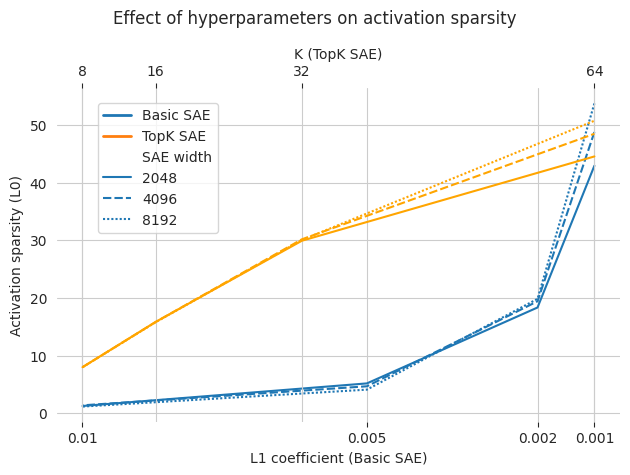

In [26]:
sns.set_style("whitegrid")
fig, ax = plt.subplots()

sns.lineplot(
    data=cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="l1",
    y="Val L0",
    ax=ax,
    style="SAE embedding dim",
)
ax2 = ax.twiny()
sns.lineplot(
    data=cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="k",
    y="Val L0",
    ax=ax2,
    style="SAE embedding dim",
    color="orange",
)
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Activation sparsity (L0)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE width"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="upper left", bbox_to_anchor=(0.15, 0.8))


fig.suptitle("Effect of hyperparameters on activation sparsity")
sns.despine(bottom=True, left=True)
plt.tight_layout()

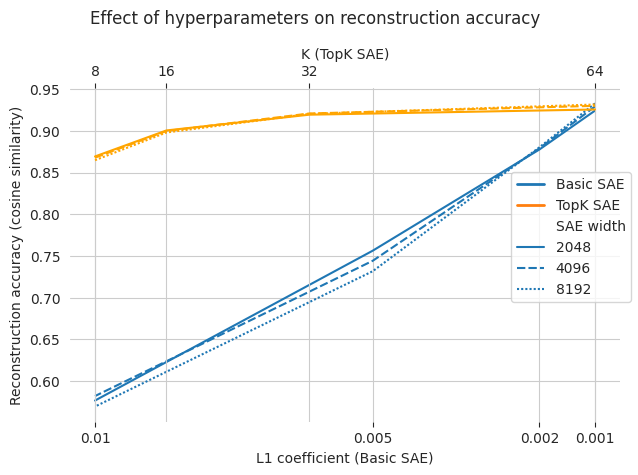

In [27]:
fig, ax = plt.subplots()

sns.lineplot(data=cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE"), x="l1", y="Mean", ax=ax, style="SAE embedding dim")
ax2 = ax.twiny()
sns.lineplot(data=cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE"), x="k", y="Mean", ax=ax2, style="SAE embedding dim", color="orange")
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Reconstruction accuracy (cosine similarity)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE width"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="center right")


fig.suptitle("Effect of hyperparameters on reconstruction accuracy")
sns.despine(bottom=True, left=True)
plt.tight_layout()

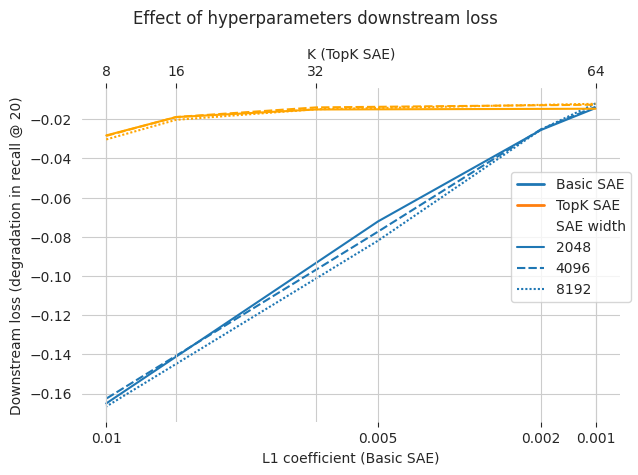

In [28]:
fig, ax = plt.subplots()

sns.lineplot(data=recall_degradation_results_1024.filter(pl.col("SAE variant") == "Basic SAE"), x="l1", y="Mean", ax=ax, style="SAE embedding dim")
ax2 = ax.twiny()
sns.lineplot(
    data=recall_degradation_results_1024.filter(pl.col("SAE variant") == "TopK SAE"), x="k", y="Mean", ax=ax2, style="SAE embedding dim", color="orange"
)
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    recall_degradation_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    recall_degradation_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    recall_degradation_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    recall_degradation_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Downstream loss (degradation in recall @ 20)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE width"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="center right")


fig.suptitle("Effect of hyperparameters downstream loss")
sns.despine(bottom=True, left=True)
plt.tight_layout()

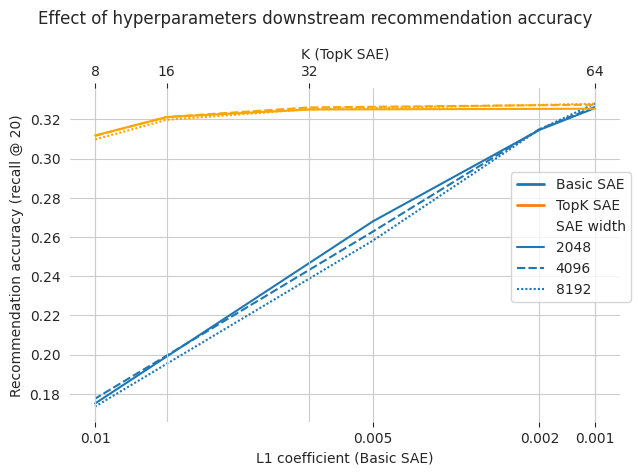

In [29]:
fig, ax = plt.subplots()

sns.lineplot(data=recall_results_1024.filter(pl.col("SAE variant") == "Basic SAE"), x="l1", y="Mean", ax=ax, style="SAE embedding dim")
ax2 = ax.twiny()
sns.lineplot(data=recall_results_1024.filter(pl.col("SAE variant") == "TopK SAE"), x="k", y="Mean", ax=ax2, style="SAE embedding dim", color="orange")
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    recall_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    recall_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    recall_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    recall_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Recommendation accuracy (recall @ 20)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE width"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="center right")


fig.suptitle("Effect of hyperparameters downstream recommendation accuracy")
sns.despine(bottom=True, left=True)
plt.tight_layout()

### Embedding dim = 4096

In [30]:
cosine_results_4096 = cosine_results.filter(pl.col("SAE embedding dim") == 4096)
recall_degradation_results_4096 = recall_degradation_results.filter(pl.col("SAE embedding dim") == 4096)
recall_results_4096 = recall_results.filter(pl.col("SAE embedding dim") == 4096)

cosine_results_4096

Checkpoint,Metric,Mean,SE,SAE variant,SAE input dim,SAE embedding dim,k,l1
str,str,f64,f64,str,i64,i64,i64,f64
"""BasicSAE-4096-1443eff9""","""Cosine similarity""",0.581966,0.001618,"""Basic SAE""",1024,4096,-1,0.01
"""BasicSAE-4096-51025ce1""","""Cosine similarity""",0.744258,0.00146,"""Basic SAE""",1024,4096,-1,0.005
"""BasicSAE-4096-a99d7c6c""","""Cosine similarity""",0.879151,0.000722,"""Basic SAE""",1024,4096,-1,0.002
"""BasicSAE-4096-882a8d66""","""Cosine similarity""",0.929276,0.000396,"""Basic SAE""",1024,4096,-1,0.001
"""TopKSAE-4096-bc1d0529""","""Cosine similarity""",0.86789,0.000674,"""TopK SAE""",1024,4096,8,0.001
"""TopKSAE-4096-aac66fc3""","""Cosine similarity""",0.899863,0.000531,"""TopK SAE""",1024,4096,16,0.001
"""TopKSAE-4096-97c35d9e""","""Cosine similarity""",0.920888,0.000433,"""TopK SAE""",1024,4096,32,0.001
"""TopKSAE-4096-2f73f56a""","""Cosine similarity""",0.930056,0.000396,"""TopK SAE""",1024,4096,64,0.001
…,…,…,…,…,…,…,…,…


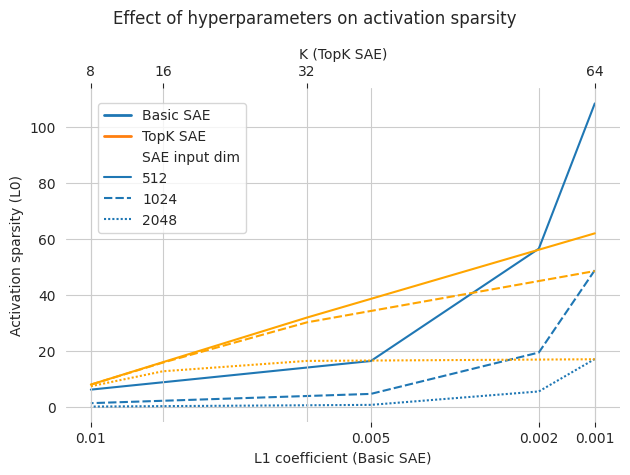

In [31]:
sns.set_style("whitegrid")
fig, ax = plt.subplots()

sns.lineplot(
    data=cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="l1",
    y="Val L0",
    ax=ax,
    style="SAE input dim",
)
ax2 = ax.twiny()
sns.lineplot(
    data=cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="k",
    y="Val L0",
    ax=ax2,
    style="SAE input dim",
    color="orange",
)
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Activation sparsity (L0)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE input dim"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="upper left", bbox_to_anchor=(0.15, 0.8))


fig.suptitle("Effect of hyperparameters on activation sparsity")
sns.despine(bottom=True, left=True)
plt.tight_layout()

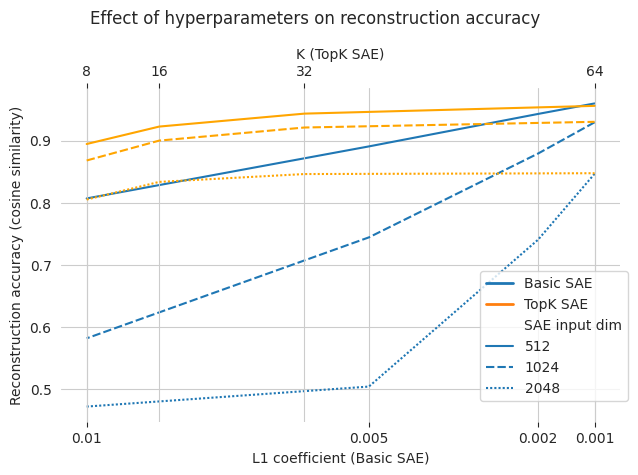

In [32]:
fig, ax = plt.subplots()

sns.lineplot(data=cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE"), x="l1", y="Mean", ax=ax, style="SAE input dim")
ax2 = ax.twiny()
sns.lineplot(data=cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE"), x="k", y="Mean", ax=ax2, style="SAE input dim", color="orange")
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Reconstruction accuracy (cosine similarity)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE input dim"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="center right", bbox_to_anchor=(1, 0.3))


fig.suptitle("Effect of hyperparameters on reconstruction accuracy")
sns.despine(bottom=True, left=True)
plt.tight_layout()

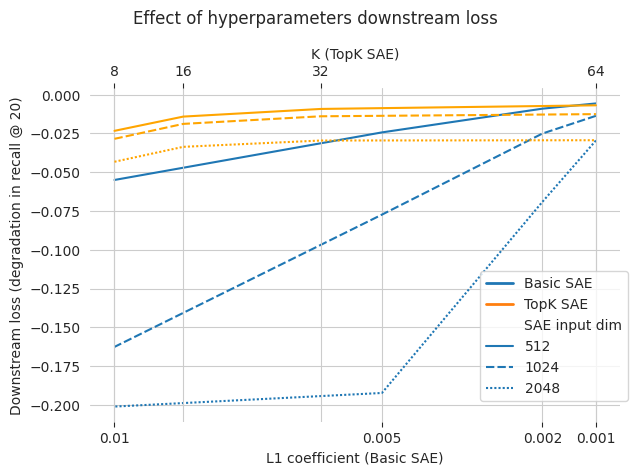

In [33]:
fig, ax = plt.subplots()

sns.lineplot(data=recall_degradation_results_4096.filter(pl.col("SAE variant") == "Basic SAE"), x="l1", y="Mean", ax=ax, style="SAE input dim")
ax2 = ax.twiny()
sns.lineplot(data=recall_degradation_results_4096.filter(pl.col("SAE variant") == "TopK SAE"), x="k", y="Mean", ax=ax2, style="SAE input dim", color="orange")
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    recall_degradation_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    recall_degradation_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    recall_degradation_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    recall_degradation_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Downstream loss (degradation in recall @ 20)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE input dim"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="center right", bbox_to_anchor=(1, 0.3))


fig.suptitle("Effect of hyperparameters downstream loss")
sns.despine(bottom=True, left=True)
plt.tight_layout()

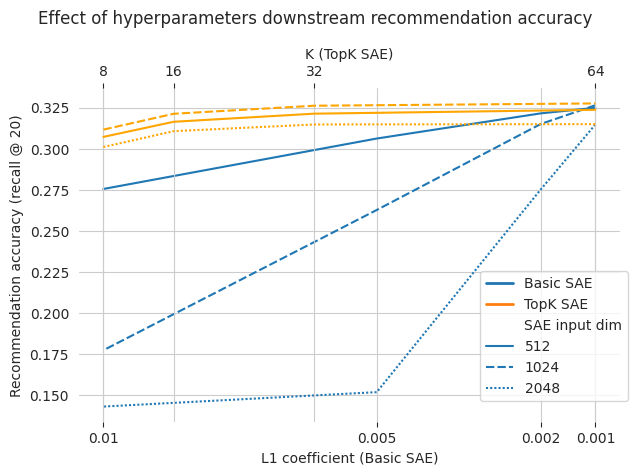

In [34]:
fig, ax = plt.subplots()

sns.lineplot(data=recall_results_4096.filter(pl.col("SAE variant") == "Basic SAE"), x="l1", y="Mean", ax=ax, style="SAE input dim")
ax2 = ax.twiny()
sns.lineplot(data=recall_results_4096.filter(pl.col("SAE variant") == "TopK SAE"), x="k", y="Mean", ax=ax2, style="SAE input dim", color="orange")
ax.set_xlabel("L1 coefficient (Basic SAE)")
ax.set_xticks(
    recall_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    recall_results_4096.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
)
ax.invert_xaxis()
ax2.set_xlabel("K (TopK SAE)")
ax2.set_xticks(
    recall_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    recall_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
ax.set_ylabel("Recommendation accuracy (recall @ 20)")

ax.legend().remove()
ax2.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = ax.get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE input dim"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="center right", bbox_to_anchor=(1, 0.3))


fig.suptitle("Effect of hyperparameters downstream recommendation accuracy")
sns.despine(bottom=True, left=True)
plt.tight_layout()

### Effect of parameters on sparsity

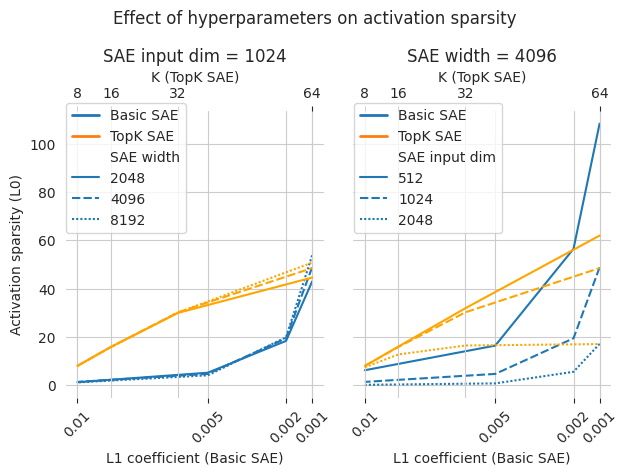

In [35]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, sharex=True, sharey=True)

sns.lineplot(
    data=cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="l1",
    y="Val L0",
    ax=axes[0],
    style="SAE embedding dim",
)
ax02 = axes[0].twiny()
sns.lineplot(
    data=cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="k",
    y="Val L0",
    ax=ax02,
    style="SAE embedding dim",
    color="orange",
)
axes[0].set_xlabel("L1 coefficient (Basic SAE)")
axes[0].set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    rotation=45,
)
axes[0].invert_xaxis()
ax02.set_xlabel("K (TopK SAE)")
ax02.set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
axes[0].set_ylabel("Activation sparsity (L0)")

axes[0].legend().remove()
ax02.legend().remove()
model_handles = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles, dim_labels = axes[0].get_legend_handles_labels()
all_handles = model_handles + [Line2D([0], [0], linestyle="None")] + dim_handles
all_labels = [h.get_label() for h in model_handles] + ["SAE width"] + dim_labels
legend = fig.legend(handles=all_handles, labels=all_labels, loc="upper left", bbox_to_anchor=(0.1, 0.8))

axes[0].set_title("SAE input dim = 1024")

sns.lineplot(
    data=cosine_results_4096.filter(pl.col("SAE variant") == "Basic SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="l1",
    y="Val L0",
    ax=axes[1],
    style="SAE input dim",
)
ax12 = axes[1].twiny()
sns.lineplot(
    data=cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE").join(losses_df.select(["Checkpoint", "Val L0"]), on="Checkpoint"),
    x="k",
    y="Val L0",
    ax=ax12,
    style="SAE input dim",
    color="orange",
)
axes[1].set_xlabel("L1 coefficient (Basic SAE)")
axes[1].set_xticks(
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    cosine_results_1024.filter(pl.col("SAE variant") == "Basic SAE")["l1"].unique(),
    rotation=45,
)
ax12.set_xlabel("K (TopK SAE)")
ax12.set_xticks(
    cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
    cosine_results_4096.filter(pl.col("SAE variant") == "TopK SAE")["k"].unique(),
)
axes[1].set_ylabel("Activation sparsity (L0)")

axes[1].legend().remove()
ax12.legend().remove()
model_handles2 = [Line2D([0], [0], color="C0", lw=2, label="Basic SAE"), Line2D([0], [0], color="C1", lw=2, label="TopK SAE")]
dim_handles2, dim_labels2 = axes[1].get_legend_handles_labels()
all_handles2 = model_handles2 + [Line2D([0], [0], linestyle="None")] + dim_handles2
all_labels2 = [h.get_label() for h in model_handles2] + ["SAE input dim"] + dim_labels2
legend2 = fig.legend(handles=all_handles2, labels=all_labels2, loc="upper left", bbox_to_anchor=(0.55, 0.8))

axes[1].set_title("SAE width = 4096")

fig.suptitle("Effect of hyperparameters on activation sparsity")
sns.despine(bottom=True, left=True)
plt.tight_layout()